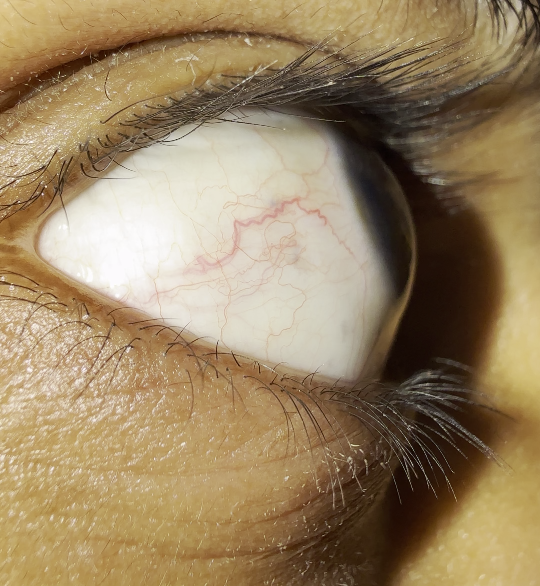

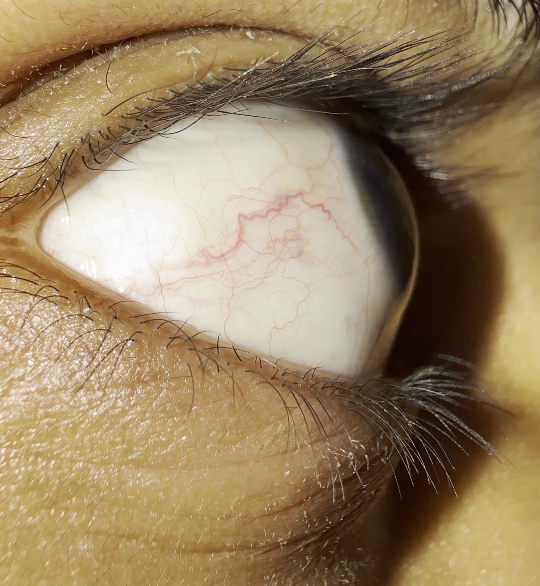

Resolution: (2344, 2160, 3), FPS: 24.0, Total Frames: 69.0, duration: 2.875 seconds


In [89]:
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

import skimage as ski


def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return

video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

cap = cv2.VideoCapture(video_source)
_ret, cap_1 = cap.read()  # Read the first frame to check if the video is valid

# get frame number 32
cap.set(cv2.CAP_PROP_POS_FRAMES, 32)
_ret, cap_32 = cap.read()
# cap_32 = cap_32[cap_32.shape[0]//4:cap_32.shape[0], :]  # crop to bottom 3/4ths
# cap_32 = cv2.imread(r"uploads\frames\frame_0011.png")  # for testing purposes, use a saved frame instead of the video frame

show(cap_1)
show(cap_32)
print(f"Resolution: {cap_1.shape}, FPS: {cap.get(cv2.CAP_PROP_FPS)}, Total Frames: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}, duration: {cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)} seconds")

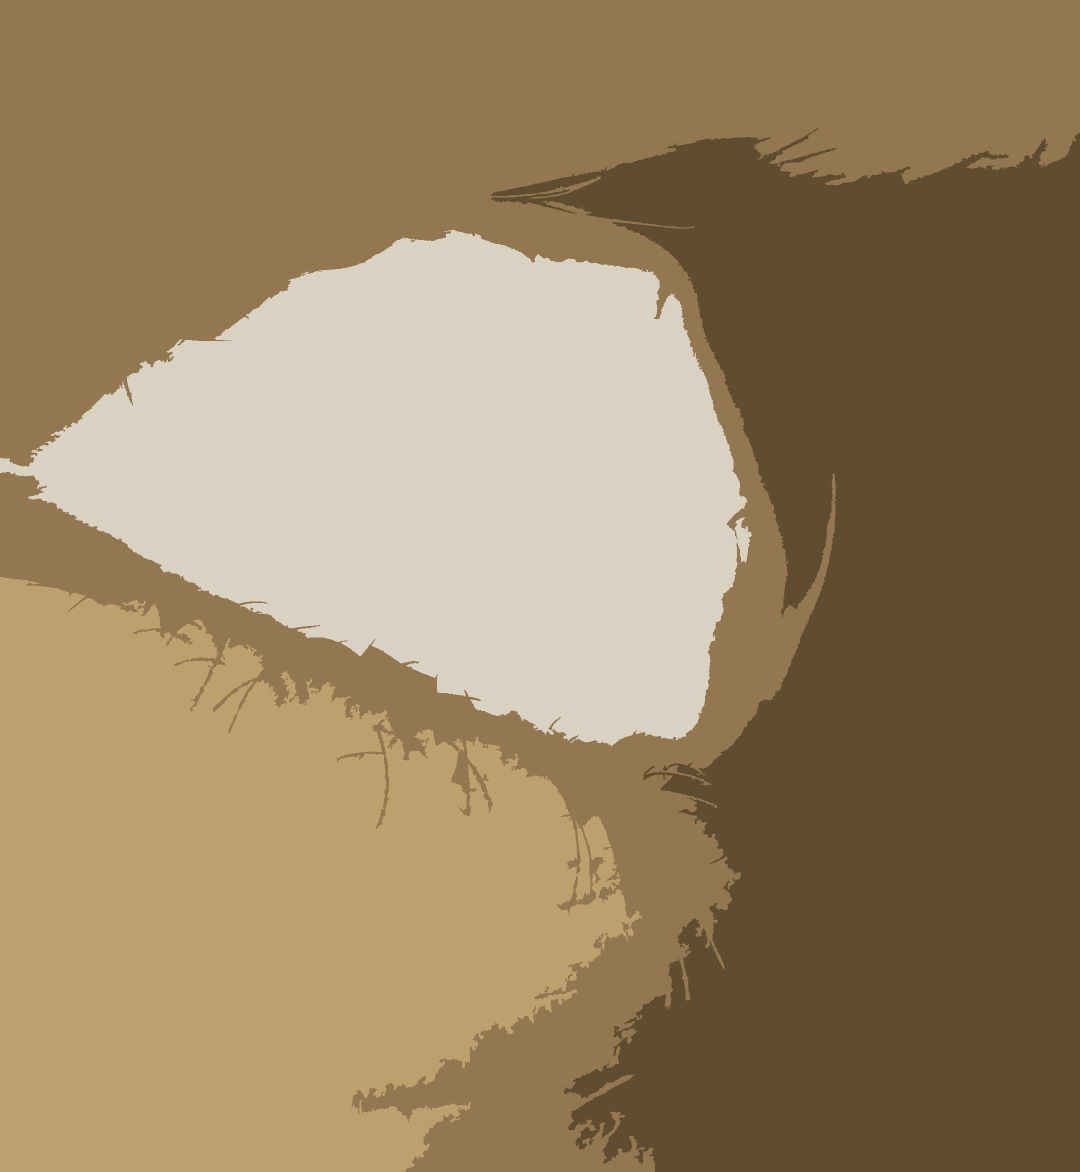

Processing time: 5207.8201 ms


In [90]:
start = cv2.getTickCount()
cap_32_seg = ski.segmentation.slic(cap_32, n_segments=4, compactness=5)
show(ski.color.label2rgb(cap_32_seg, cap_32, kind='avg'), .5)
end = cv2.getTickCount()
print(f"Processing time: {(end - start) / cv2.getTickFrequency() * 1000} ms")

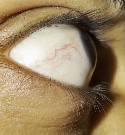

In [91]:
import numpy as np

# cap_32_blur = cv2.blur(cap_32, (51, 51))
aspect_ratio = cap_32.shape[1] / cap_32.shape[0]
new_w = 500
if new_w > cap_32.shape[1]:
    new_w = int(cap_32.shape[1] * .25)
new_h = int(new_w / aspect_ratio)

cap_32_lowRes = cv2.resize(cap_32, (new_w, new_h), interpolation=cv2.INTER_AREA)
# cap_32_lowRes = cap_32_lowRes[new_h//4:new_h, :]  # crop to bottom 3/4ths
show(cap_32_lowRes)

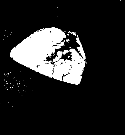

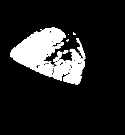

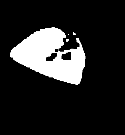

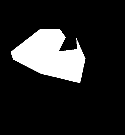

In [105]:
cap_32_hsv = cv2.cvtColor(cap_32_lowRes, cv2.COLOR_BGR2HSV)

thresh_hsv = cv2.inRange(cap_32_hsv, (0, 1, 180), (180, 35, 255))
opened_hsv = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
close_hsv = cv2.morphologyEx(opened_hsv, cv2.MORPH_CLOSE, np.ones((11,11), np.uint8))
larg_Contour, _ = cv2.findContours(close_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(larg_Contour, key=cv2.contourArea) if larg_Contour else None
peri = cv2.arcLength(largest_contour, True)
simplified_contour = cv2.approxPolyDP(largest_contour, epsilon=0.015 * peri, closed=True)
#  get the corresponding mask of the largest contour
mask = np.zeros_like(close_hsv)
mask = cv2.drawContours(mask, [simplified_contour], -1, 255, thickness=cv2.FILLED)
    
show(thresh_hsv)
show(opened_hsv)
show(close_hsv)
show(mask)


homogeneous coords shape: (51, 3) and values: [[33. 75.  1.]
 [33. 80.  1.]
 [34. 81.  1.]
 [34. 83.  1.]
 [35. 84.  1.]]
contour_img shape: (854, 480, 3)
contour_img pixel at ([325 325 325 325 325], [132 133 134 135 136]): [[173   0   0]
 [182   0   0]
 [188   0   0]
 [198   0   0]
 [203   0   0]]
mask shape: (854, 480, 3) cap_32.shape: (854, 480, 3)


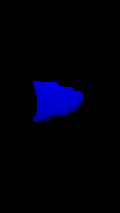

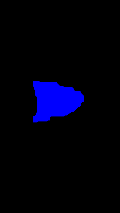

In [88]:

# Take the contour coords and multiply by a transformation matrix to get the corresponding coords in the original image, then draw the contour on the original image
M = np.array([[cap_32.shape[1] / new_w, 0, 0],
              [0, cap_32.shape[0] / new_h, 25],
              [0, 0, 1]])

# make the contour coords homogeneous
# take out one of the wrappers for the contour coords
homogeneous_coords = np.hstack([largest_contour.reshape(-1, 2), np.ones((largest_contour.shape[0], 1))])
print(f"homogeneous coords shape: {homogeneous_coords.shape} and values: {homogeneous_coords[:5]}")
transformed_coords = (M @ homogeneous_coords.T).T[:, :2].astype(int)

# draw the contour on the original image
contour_img = cap_32.copy()
contour_zero = np.zeros_like(contour_img)
mask = cv2.drawContours(contour_zero, [transformed_coords], -1, 255, thickness=cv2.FILLED)
contour_img = cap_32 * mask.astype(bool)
print(f"contour_img shape: {contour_img.shape}")

#debugging code to look for good pixels
nonzero_mask = np.any(contour_img != 0, axis=2)  # shape: (1080, 1280)
rows, cols = np.where(nonzero_mask)

print(f"contour_img pixel at ({rows[0:5]}, {cols[0:5]}): {contour_img[rows[0:5], cols[0:5]]}")
# print(f"contour_img values: {np.unique(contour_img)}") # use numpy to show me a pixel with values
print(f"mask shape: {mask.shape} cap_32.shape: {cap_32.shape}")
show(contour_img)


show(mask)


In [ ]:


# cap_32_gaussian = cv2.GaussianBlur(cap_32_blur, (3,3), 0)
cap_32_gaussian_lowRes = cv2.GaussianBlur(cap_32_lowRes, (3,3), 3)
# cap_32_lowRes = cv2.pyrDown(cap_32_lowRes)

# cap_32_lowRes = cv2.resize(cap_32_lowRes, (cap_32.shape[1], cap_32.shape[0]))

cap_32_gaussian_lowRes = cv2.resize(cap_32_gaussian_lowRes, (cap_32.shape[1], cap_32.shape[0]))
# cap_32 = cap_32_blur.astype(np.float32)
# show(cap_32_blur, scale_factor=.5)
show(cap_32_lowRes, scale_factor=.5)
# show(cap_32_gaussian, scale_factor=.5)
show(cap_32_gaussian_lowRes, scale_factor=.5)
# cap_32_bilat = cv2.bilateralFilter(cap_32_blur, d=5, sigmaColor=500, sigmaSpace=1)
# calculate the difference between bilateral and original
# cap_32_diff = cv2.absdiff(cap_32, cap_32_bilat)
# print(f"Mean: {np.mean(cap_32_diff)}, Std: {np.std(cap_32_diff)}, Max: {np.max(cap_32_diff)}, Min: {np.min(cap_32_diff)}")
# cv2.imshow("Gaussian", cap_32_gaussian)
# cv2.imshow("Bilateral", cap_32_bilat)
# display(Image.fromarray(cv2.cvtColor(cap_32_gaussian.astype(np.uint8), cv2.COLOR_BGR2RGB))))
# scale down the bilateral image for display
# cap_32_bilat_display = cv2.resize(cap_32_bilat, (0, 0), fx=0.25, fy=0.25)
# display(Image.fromarray(cv2.cvtColor(cap_32_bilat_display.astype(np.uint8), cv2.COLOR_BGR2RGB)))



In [ ]:
SCALE = 1 / 16  # equivalent to 4x pyrDown

def get_largest_bright_contour(frame: np.ndarray) -> np.ndarray:
    # h, w = frame.shape[:2]
    # low_res_w, low_res_h = int(w * SCALE), int(h * SCALE)
    # low_res = cv2.resize(frame, (low_res_w, low_res_h), interpolation=cv2.INTER_AREA)
    # Option 1: Large Gaussian blur — closest equivalent to pyrDown x4
    blurred = cv2.GaussianBlur(frame, (31, 31), 8)

    # Option 2: Box filter — faster than Gaussian, less smooth
    blurred = cv2.boxFilter(frame, -1, (32, 32))

    # Option 3: Median blur — also kills noise but preserves edges slightly better
    blurred = cv2.medianBlur(frame, 67)  # must be odd

    # Option 4: Bilateral filter — preserves edges while blurring flat regions
    # blurred = cv2.bilateralFilter(frame, 15, 80, 80)

    # Single resize replaces 4x pyrDown + GaussianBlur + resize back
    low_res = blurred
    show(low_res, scale_factor=.25)
    # Extract V channel only — avoids full HSV conversion
    hsv_image = cv2.cvtColor(low_res, cv2.COLOR_BGR2HSV)
    show(hsv_image, scale_factor=.25)
    mask = cv2.inRange(hsv_image, (0, 1, 180), (180, 35, 255))  # keep if HSV range needed
    # show(mask, scale_factor=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

    # connectedComponentsWithStats gives area directly — no need for max(contours, key=contourArea)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    # print(f"Found {num_labels - 1} bright components in low-res image")
    # print(f"stats: {stats}")  # skip label 0 (background)

    # Skip label 0 (background), find largest component

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest_mask = np.uint8(cv2.connectedComponents(mask)[1] == largest_label) * 255

    # Get contour of largest component and scale back to original resolution
    contours, _ = cv2.findContours(largest_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return (contours[0] / SCALE).astype(np.int32)

# show(cap_32, scale_factor=.5)
largest_contour = get_largest_bright_contour(cap_32)
# Draw the largest contour on a copy of the original image
contour_img = cap_32.copy()
contour_img = cv2.drawContours(contour_img, [largest_contour], -1, (0, 255, 0), 2)
show(contour_img, scale_factor=.25)


In [ ]:
def draw_contour(largest_contour):
    contour_img = cap_32.copy()
    cv2.drawContours(contour_img, [largest_contour], -1, (0, 255, 0), 2)
    show(contour_img)

# select the largetst contour in the thresh_hsv image
contours, _ = cv2.findContours(thresh_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)


draw_contour(largest_contour)

In [ ]:
roi = cv2.imread("IMG_1735_F32.png")
show(roi)
# cv2.imwrite("IMG_1735_F32.png", cap_32)


In [ ]:
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

cap_32_hsv = cv2.cvtColor(cap_32, cv2.COLOR_BGR2HSV)
cap_32_equalized = cv2.equalizeHist(cap_32_hsv[:, :, 2])
import matplotlib.pyplot as plt

# OpenCV HSV ranges: H=[0,179], S=[0,255], V=[0,255]
h = roi_hsv[:, :, 0].astype(np.float32) / 179.0
s = roi_hsv[:, :, 1].astype(np.float32) # / 255.0
v = roi_hsv[:, :, 2].astype(np.float32) # / 255.0

cap_h = cap_32_hsv[:, :, 0].astype(np.float32) / 179.0
cap_s = cap_32_hsv[:, :, 1].astype(np.float32) #
cap_v = cap_32_hsv[:, :, 2].astype(np.float32) #

plt.hist(s.ravel(), bins=256, range=(0, 255), color='blue', alpha=0.5, label='Saturation')
plt.hist(v.ravel(), bins=256, range=(0, 255), color='orange', alpha=0.5, label='Value')

plt.hist(cap_s.ravel(), bins=256, range=(0, 255), color='green', alpha=0.5, label='Total Saturation')
plt.hist(cap_v.ravel(), bins=256, range=(0, 255), color='purple', alpha=0.5, label='Total Value')

# plt.hist(h.ravel(), bins=180, range=(0, 1), color='green', alpha=0.5, label='Hue')
plt.title("Saturation and Brightness Histograms")
plt.xlabel("Value")
plt.ylabel("Frequency")
# set y-axis scale 1- 50000
# plt.yticks(np.arange(0, 50001, 5000))
plt.ylim(0, 50000)
plt.yticks(np.arange(0, 50001, 5000))
plt.xlim(0, 255)
plt.xticks(np.arange(0, 256, 25))
plt.vlines(x=[35, 185], ymax=50000, ymin=0, colors='blue')
plt.legend()
# plt.savefig("histograms.png")
# plt.close()


plt.tight_layout()



# show(roi_hsv[:,:,1])

In [ ]:
roi_hsv_thresh = cv2.inRange(roi_hsv, (0, 1, 180), (180, 25, 252))
show(roi_hsv_thresh)

In [ ]:
# clean speckles in thresh_hsv using morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
thresh_hsv_ex = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, kernel)
show(thresh_hsv_ex)

In [ ]:
cv2.useOptimized()